### Tests for Soroe

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyAPES.microclimate.radiation import solar_angles
from pyAPES.utils.constants import DEG_TO_RAD


In [2]:
from pyAPES.leaf.photo import Vcmax_from_Nleaf

x = Vcmax_from_Nleaf(2.0, 'Temperate broadleaf')

In [6]:
1.9 * x

125.704

In [ ]:
a = [5.9, 7.3, 8.75, 9.7]
b = [9.6, 3.2, -0.5, 4.5, 7.5]

print(np.mean(a), np.std(b), np.mean(b), np.std(b))


In [3]:
raw = pd.read_csv(r'data\tmp\soroe_laidev.txt', sep=',', skipinitialspace=True)

# restrict to doy [0, 310]
raw = raw[raw['doy'] <= 325].copy()

# inverted normalization: minimum contributes to maximum LAI and maximum to minimum LAI
# use 5th percentile as the lower reference and actual max as upper reference
val_min = np.percentile(raw['value'], 5)
val_max = raw['value'].max()
raw['rLAI'] = 1 - (raw['value'] - val_min) / (val_max - val_min)
raw['rLAI'] = raw['rLAI'].clip(0, 1)

met = pd.read_csv(r'forcing/Soroe/DK-Sor_forcing_2015-2020.dat', sep=';')

# compute solar angles
lat = 55.486 # N
lon = 11.644 # E
timeoffset = 1.15 # accounts for +1 UTC and 15min correction due to timestep being ENDTIME of 30min period

jday = met['doy'] + met['hour'] / 24 + met['minute'] / (24*60)

jday = jday.values

zen, azim, decl, sunrise, sunset, daylength = solar_angles(lat, lon, jday, timezone=timeoffset)
elev_angle = 90 - zen / DEG_TO_RAD

met['daylength'] = daylength / 60 # hours
met['elev_angle'] = elev_angle


In [ ]:
plt.plot(raw['doy'], raw['rLAI'], '.-')

In [4]:
met2018 = (met.loc[met['year'] == 2018, ['doy', 'DDsum', 'Tdaily', 'daylength']]
             .groupby('doy')
             .agg({'DDsum': 'last', 'Tdaily': 'first', 'daylength': 'max'}))

In [5]:
met2018.head()

,DDsum,Tdaily,daylength
doy,,,
1,0.0,5.604,7.189827
2,0.0,4.324,7.214096
3,0.0,3.031,7.240383
4,0.0,2.547,7.268656
5,0.0,1.950,7.298876


In [ ]:
from scipy.optimize import differential_evolution

def simulate_rLAI(params, met2018):
    """Simulate relative LAI for each day in met2018.
    
    Uses met2018['DDsum'] directly. Tbase is fixed at 5.0.
    params: [lai_min, ddo, ddmat, sdl, sdur]
    """
    lai_min, ddo, ddmat, sdl, sdur = params

    # senescence onset: last doy on the descending side where daylength >= sdl
    doys = met2018.index.values
    dl = met2018['daylength'].values
    # only look at post-solstice (doy > 172) to avoid spring false-positive
    post_sol = doys > 172
    mask = (dl >= sdl) & post_sol
    sso = int(doys[mask][-1]) if mask.any() else 200

    rLAI = []

    for doy_i, row in met2018.iterrows():
        DDsum = row['DDsum']

        # spring growth phase
        if DDsum <= ddo:
            f = lai_min
        else:
            f = min(1.0, lai_min + (1.0 - lai_min) * (DDsum - ddo) / (ddmat - ddo))

        # autumn senescence: linear decline over sdur days
        if doy_i > sso:
            f = 1.0 - (1.0 - lai_min) * min(1.0, (doy_i - sso) / sdur)

        rLAI.append(f)

    return pd.Series(rLAI, index=met2018.index)


def objective(params):
    lai_min, ddo, ddmat, sdl, sdur = params
    if ddmat <= ddo or lai_min <= 0 or lai_min >= 1 or sdur <= 0:
        return 1e9
    sim = simulate_rLAI(params, met2018)
    sim_at_obs = np.interp(raw['doy'].values, sim.index.values, sim.values)
    return np.sum((sim_at_obs - raw['rLAI'].values) ** 2)


# --- bounds ---
# [lai_min,      ddo,       ddmat,      sdl,      sdur ]
bounds = [(0.01, 0.5), (20, 200), (100, 600), (8, 14), (10, 120)]

# differential_evolution: derivative-free global search
# works correctly with the discrete step-function nature of sso(sdl)
result = differential_evolution(objective, bounds, seed=42,
                                maxiter=1000, tol=1e-6, polish=True)

lai_min_opt, ddo_opt, ddmat_opt, sdl_opt, sdur_opt = result.x

print("Optimized parameters (Tbase fixed at 5.0 °C):")
print(f"  lai_min = {lai_min_opt:.3f}")
print(f"  ddo     = {ddo_opt:.1f}  °C·day  (budburst)")
print(f"  ddmat   = {ddmat_opt:.1f}  °C·day  (full canopy)")
print(f"  sdl     = {sdl_opt:.2f} h  (senescence daylength threshold)")
print(f"  sdur    = {sdur_opt:.1f}  days  (senescence duration)")
print(f"  SSE     = {result.fun:.4f}")

# --- plot ---
sim_opt = simulate_rLAI(result.x, met2018)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(raw['doy'], raw['rLAI'], 'o', ms=4, label='observed (2018)')
ax.plot(sim_opt.index, sim_opt.values, '-', lw=2, label='fitted')
ax.set_xlabel('Day of year')
ax.set_ylabel('Relative LAI')
ax.legend()
plt.tight_layout()
plt.show()


Leaf Nitrogen and Vcmax

In [ ]:
def Vcmax_from_Nleaf(N, pft):
    #Kattge et al. 2009 GCB Table 2
    pft_params = {
        "Tropical trees (oxisols)": {"iV": 1.99, "SD_iV": 5.14, "sV": 10.71, "SD_sV": 1.90, "corr": -0.93},
          

        "Tropical trees (nonoxisols)": {"iV": 6.35, "SD_iV": 5.52, "sV": 25.88, "SD_sV": 5.16, "corr": -0.93},

        "Temperate broadleaved trees": {"iV": 5.40, "SD_iV": 1.74, "sV": 30.38, "SD_sV": 1.34, "corr": -0.90},

        "Coniferous trees": {"iV": 34.05, "SD_iV": 5.90, "sV": 9.71, "SD_sV": 2.26, "corr": -0.91},

        "Shrubs": {"iV": 4.61, "SD_iV": 8.22, "sV": 30.20, "SD_sV": 4.77, "corr": -0.93},

        "C3 herbaceous": {"iV": 23.74, "SD_iV": 6.87, "sV": 28.17, "SD_sV": 4.67, "corr": -0.96},
        "C3 crops": {"iV": 22.22, "SD_iV": 16.74, "sV": 41.27, "SD_sV": 12.53, "corr": -0.96},
    }

    a0 = pft_params[pft]['iV']
    a1 = pft_params[pft]['sV']
    
    vmax25 = a0 + a1 * N
    return vmax25

        # if 'kn' in self.photop0:
        #     kn = self.photop0['kn']
        #     Lc = np.flipud(np.cumsum(np.flipud(self.lad*self.dz)))
        #     Lc = Lc / np.maximum(Lc[0], EPS)
        #     f = np.exp(-kn*Lc)
def canopygradient(kn, Lc):
    Lc = Lc / np.maximum(Lc[-1], 0.0001)
    print(Lc)
    f = np.exp(-kn*Lc)
    return f



In [ ]:
Lc = [0.0, 2.5, 5.0]
kn = 0.5
Ntop = 2.5

N = Ntop*canopygradient(kn, Lc)

Vmax25 = Vcmax_from_Nleaf(2.5, 'Temperate broadleaved trees')
print(Vmax25)


## Vcmax seasonal cycle – Wilson et al. (2001) PCE Fig. 4

Three **exponential** phases, same parameterization as DDsum/daylength `LAI_cycle`:

1. **Spring recovery** — DDsum-based exponential rise from `fmin` → 1.0 (`ddo` to `ddmat`)
2. **Gradual summer decline** — exponential 1.0 → `f_sso` between full maturity (`ddmat`) and senescence onset (`sso`)
3. **Rapid senescence** — exponential `f_sso` → `fmin` over `sdur` days after `sso`

Control points are identical to the linear version; only the curvature changes.


Senescence onset DOY (daylength = 10.5 h): 286


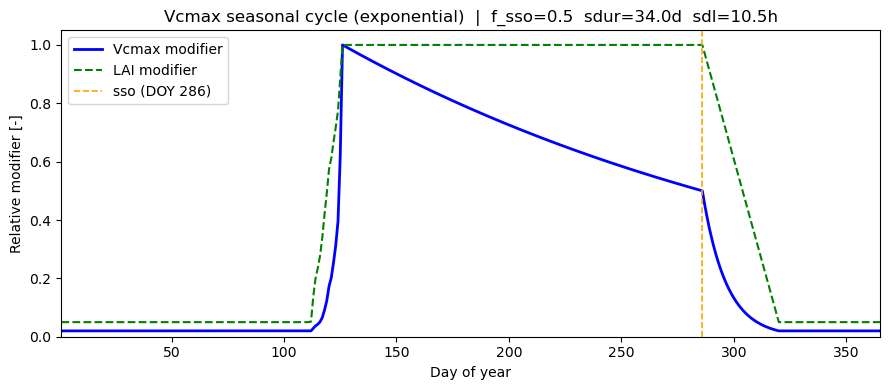

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from pyAPES.planttype.phenology import daylength

# ── site ──────────────────────────────────────────────────────────────────────
lat, lon = 55.486, 11.644   # DK-Sor (Soroe)

# ── parameters (tunable) ──────────────────────────────────────────────────────
Tbase  = 5.0    # base temperature for DDsum [degC]
ddo    = 95.0   # DDsum at bud burst [degC d]
ddmat  = 162.0  # DDsum at full Vcmax maturity [degC d]
sdl    = 10.5   # daylength threshold for senescence onset [h]
sdur   = 34.0   # senescence duration [days]
f_sso  = 0.5    # relative Vcmax at senescence onset [-]  ← key parameter
fmin   = 0.02   # minimum (fully senesced) [-]

# ── build daylength-based sso from 2018 forcing ──────────────────────────────
doys_all = met2018.index.values
dl_arr   = daylength(lat=lat, lon=lon, doy=doys_all)
post_sol = doys_all > 172
sso_idx  = np.max(np.where((dl_arr >= sdl) & post_sol))
sso      = int(doys_all[sso_idx])
print(f'Senescence onset DOY (daylength = {sdl} h): {sso}')

# ── simulate one year ─────────────────────────────────────────────────────────
def simulate_vcmax_cycle(met2018, Tbase, ddo, ddmat, sso, sdur, f_sso, fmin):
    """
    Relative Vcmax modifier – three-phase exponential model.
    Same parameters as before; f(a→b, t) = a * (b/a)^t.
    Returns a pd.Series indexed by DOY.
    """
    f_vals  = []
    mat_doy = None  # first DOY ddmat is exceeded

    for doy, row in met2018.iterrows():
        DDsum = row['DDsum']

        # phase 1: exponential spring recovery (fmin → 1.0)
        if DDsum <= ddo:
            f = fmin
        elif DDsum < ddmat:
            t = (DDsum - ddo) / (ddmat - ddo)          # 0 → 1
            f = fmin * (1.0 / fmin) ** t               # exponential rise
        else:
            f = 1.0

        # phase 2: exponential summer decline (1.0 → f_sso, mat_doy → sso)
        if DDsum >= ddmat and doy <= sso:
            if mat_doy is None:
                mat_doy = doy
            span = max(1, sso - mat_doy)
            t = min(1.0, max(0.0, (doy - mat_doy) / span))
            f = f_sso ** t                             # 1.0 * (f_sso/1.0)^t

        # phase 3: exponential senescence (f_sso → fmin)
        if doy > sso:
            t = min(1.0, (doy - sso) / sdur)
            f = max(fmin, f_sso * (fmin / f_sso) ** t)

        f_vals.append(f)

    import pandas as pd
    return pd.Series(f_vals, index=met2018.index)


f_vcmax = simulate_vcmax_cycle(met2018, Tbase, ddo, ddmat, sso, sdur, f_sso, fmin)

# also get simulated LAI cycle for comparison
from pyAPES.parameters.mlm_parameters_Soroe import gpara, cpara
loc = cpara['loc']
from pyAPES.planttype.phenology import LAI_cycle
laip = list(cpara['planttypes'].values())[0]['laip']
lai_model = LAI_cycle(laip, loc)
f_lai = []
for doy, row in met2018.iterrows():
    f_lai.append(lai_model.run(doy, row['Tdaily'], out=True))
import pandas as pd
f_lai = pd.Series(f_lai, index=met2018.index)

# ── plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(f_vcmax.index, f_vcmax.values, 'b-',  lw=2, label='Vcmax modifier')
ax.plot(f_lai.index,   f_lai.values,   'g--', lw=1.5, label='LAI modifier')
ax.axvline(sso, color='orange', ls='--', lw=1.2, label=f'sso (DOY {sso})')
ax.set_xlabel('Day of year')
ax.set_ylabel('Relative modifier [-]')
ax.set_title(f'Vcmax seasonal cycle (exponential)  |  f_sso={f_sso}  sdur={sdur}d  sdl={sdl}h')
ax.set_xlim(1, 365); ax.set_ylim(0, 1.05)
ax.legend()
plt.tight_layout()
plt.show()


In [ ]:
from pyAPES.planttype.phenology import daylength as _daylength

class VcmaxSeasonalCycle:
    """
    DDsum + daylength three-phase seasonal acclimation of photosynthetic capacity.
    Modifier scalar for Vcmax25, Jmax25, Rd25.

    Parameters (p dict)
    -------------------
    Tbase : base temperature for DDsum accumulation [degC]
    ddo   : DDsum at bud burst [degC d]
    ddmat : DDsum at full Vcmax maturity [degC d]
    sdl   : daylength threshold for senescence onset [h]
    sdur  : senescence duration [days]
    f_sso : relative Vcmax at senescence onset [-]
    fmin  : winter minimum [-]

    loc dict must contain 'lat' and 'lon' [decimal degrees].
    """

    def __init__(self, p, loc):
        self.Tbase = p['Tbase']
        self.ddo   = p['ddo']
        self.ddmat = p['ddmat']
        self.sdl   = p['sdl']
        self.sdur  = p['sdur']
        self.f_sso = p['f_sso']
        self.fmin  = p['fmin']

        # precompute sso: last post-solstice DOY where daylength >= sdl
        doys     = np.arange(1, 366)
        dl_arr   = _daylength(lat=loc['lat'], lon=loc['lon'], doy=doys)
        post_sol = doys > 172
        mask     = (dl_arr >= self.sdl) & post_sol
        self.sso = int(doys[mask][-1]) if mask.any() else 258

        self.DDsum   = 0.0
        self.mat_doy = None   # first DOY ddmat was exceeded
        self.f       = self.fmin

    def run(self, doy, T):
        """
        Advance one daily timestep.

        Parameters
        ----------
        doy : int   day of year (1–365)
        T   : float mean daily air temperature [degC]

        Returns
        -------
        float  relative Vcmax modifier [-]
        """
        fmin  = self.fmin
        f_sso = self.f_sso
        sso   = self.sso

        # reset DDsum at start of each year
        if doy == 1:
            self.DDsum   = 0.0
            self.mat_doy = None

        self.DDsum += np.maximum(0.0, T - self.Tbase)

        # phase 1: exponential spring recovery (fmin → 1.0)
        if self.DDsum <= self.ddo:
            f = fmin
        elif self.DDsum < self.ddmat:
            t = (self.DDsum - self.ddo) / (self.ddmat - self.ddo)
            f = fmin * (1.0 / fmin) ** t
        else:
            f = 1.0

        # phase 2: exponential summer decline (1.0 → f_sso)
        if self.DDsum >= self.ddmat and doy <= sso:
            if self.mat_doy is None:
                self.mat_doy = doy
            span = max(1, sso - self.mat_doy)
            t = min(1.0, max(0.0, (doy - self.mat_doy) / span))
            f = f_sso ** t

        # phase 3: exponential senescence (f_sso → fmin)
        if doy > sso:
            t = min(1.0, (doy - sso) / self.sdur)
            f = max(fmin, f_sso * (fmin / f_sso) ** t)

        self.f = f
        return self.f


# ── run one year with daily temperature ──────────────────────────────────────
vcmax_params = dict(Tbase=Tbase, ddo=ddo, ddmat=ddmat, sdl=sdl,
                    sdur=sdur, f_sso=f_sso, fmin=fmin)
loc_soroe = dict(lat=lat, lon=lon)

model = VcmaxSeasonalCycle(vcmax_params, loc_soroe)
print(f'Precomputed sso: DOY {model.sso}')

f_class = pd.Series(
    [model.run(doy, row['Tdaily']) for doy, row in met2018.iterrows()],
    index=met2018.index
)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(f_vcmax.index, f_vcmax.values, 'b-',  lw=2.5, label='function (DDsum from forcing)')
ax.plot(f_class.index, f_class.values, 'r--', lw=1.5, label='class (DDsum from Tdaily)')
ax.axvline(model.sso, color='orange', ls='--', lw=1.2, label=f'sso (DOY {model.sso})')
ax.set_xlabel('Day of year'); ax.set_ylabel('Relative Vcmax [-]')
ax.set_title('VcmaxSeasonalCycle class — one-year run driven by Tdaily')
ax.set_xlim(1, 365); ax.set_ylim(0, 1.05)
ax.legend(); plt.tight_layout(); plt.show()


In [ ]:
# ── sensitivity: f_sso and sdur ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
fig.suptitle('Parameter sensitivity of Vcmax seasonal cycle')

for f_val in [0.7, 0.6, 0.5, 0.4, 0.3]:
    f = simulate_vcmax_cycle(met2018, Tbase, ddo, ddmat, sso, sdur, f_val, fmin)
    axes[0].plot(f.index, f.values, label=f'{f_val:.1f}')
axes[0].axvline(sso, color='orange', ls='--', lw=1)
axes[0].set_title('f_sso  (Vcmax at senescence onset)')
axes[0].set_xlabel('DOY'); axes[0].set_ylabel('Relative Vcmax [-]')
axes[0].legend(title='f_sso', fontsize=8)

for sdur_val in [20, 30, 40, 60]:
    f = simulate_vcmax_cycle(met2018, Tbase, ddo, ddmat, sso, sdur_val, f_sso, fmin)
    axes[1].plot(f.index, f.values, label=f'{sdur_val}')
axes[1].axvline(sso, color='orange', ls='--', lw=1)
axes[1].set_title('sdur  (senescence duration [days])')
axes[1].set_xlabel('DOY')
axes[1].legend(title='sdur', fontsize=8)

plt.tight_layout()
plt.show()
